In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
# Load dataset
df = pd.read_csv("COVID-19_RECOVERY_DATASET.csv")

In [6]:
df.head()

,patient_id,country,region/state,date_reported,age,gender,comorbidities,symptoms_1,symptoms_2,symptoms_3,...,days_to_recovery,recovered,death,date_of_recovery,date_of_death,tests_conducted,test_type,hospital_name,doctor_assigned,source_url
0,P000001,India,Sindh,44447,95,Female,Diabetes,Cough,NaN,NaN,...,18,0,1,44465.0,NaN,1,PCR,Aga Khan,Dr. Müller,https://who.int/sample
1,P000002,Pakistan,London,43930,92,Female,Diabetes,Loss of Smell,Fatigue,Fatigue,...,9,0,1,43939.0,NaN,3,PCR,Jinnah Hospital,Dr. Silva,https://who.int/sample
2,P000003,Germany,Berlin,44718,78,Female,NaN,Headache,Loss of Smell,Loss of Smell,...,27,0,1,44745.0,NaN,2,Antigen,Jinnah Hospital,Dr. Smith,https://who.int/sample
3,P000004,India,Cape Town,44107,36,Female,Cancer,Cough,Fatigue,Fatigue,...,25,1,1,44132.0,NaN,2,PCR,Mayo Clinic,Dr. Silva,https://who.int/sample
4,P000005,UK,Berlin,44083,99,Male,Diabetes,Fatigue,NaN,NaN,...,17,0,0,NaN,44123.0,4,PCR,AIIMS,Dr. Smith,https://who.int/sample


In [8]:
df.shape

(1000, 28)

In [9]:
df.columns.tolist()

['patient_id',
 'country',
 'region/state',
 'date_reported',
 'age',
 'gender',
 'comorbidities',
 'symptoms_1',
 'symptoms_2',
 'symptoms_3',
 'severity',
 'hospitalized',
 'icu_admission',
 'ventilator_support',
 'vaccination_status',
 'variant',
 'treatment_given_1',
 'treatment_given_2',
 'days_to_recovery',
 'recovered',
 'death',
 'date_of_recovery',
 'date_of_death',
 'tests_conducted',
 'test_type',
 'hospital_name',
 'doctor_assigned',
 'source_url']

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          1000 non-null   object 
 1   country             1000 non-null   object 
 2   region/state        1000 non-null   object 
 3   date_reported       1000 non-null   int64  
 4   age                 1000 non-null   int64  
 5   gender              1000 non-null   object 
 6   comorbidities       818 non-null    object 
 7   symptoms_1          1000 non-null   object 
 8   symptoms_2          681 non-null    object 
 9   symptoms_3          678 non-null    object 
 10  severity            1000 non-null   object 
 11  hospitalized        1000 non-null   int64  
 12  icu_admission       1000 non-null   int64  
 13  ventilator_support  1000 non-null   int64  
 14  vaccination_status  609 non-null    object 
 15  variant             1000 non-null   object 
 16  treatme

In [11]:
df.isnull().sum()

patient_id              0
country                 0
region/state            0
date_reported           0
age                     0
gender                  0
comorbidities         182
symptoms_1              0
symptoms_2            319
symptoms_3            322
severity                0
hospitalized            0
icu_admission           0
ventilator_support      0
vaccination_status    391
variant                 0
treatment_given_1       0
treatment_given_2     489
days_to_recovery        0
recovered               0
death                   0
date_of_recovery      250
date_of_death         750
tests_conducted         0
test_type               0
hospital_name           0
doctor_assigned         0
source_url              0
dtype: int64

In [12]:
target = "recovered"

In [13]:
drop_columns = [
    "patient_id",
    "source_url",
    "doctor_assigned",
    "date_of_recovery",
    "date_of_death",
    "days_to_recovery"
]

drop_columns = [col for col in drop_columns if col in df.columns]

df = df.drop(columns=drop_columns)

In [14]:
df.head()

,country,region/state,date_reported,age,gender,comorbidities,symptoms_1,symptoms_2,symptoms_3,severity,...,ventilator_support,vaccination_status,variant,treatment_given_1,treatment_given_2,recovered,death,tests_conducted,test_type,hospital_name
0,India,Sindh,44447,95,Female,Diabetes,Cough,NaN,NaN,Moderate,...,1,Full,Omicron,Antibiotics,NaN,0,1,1,PCR,Aga Khan
1,Pakistan,London,43930,92,Female,Diabetes,Loss of Smell,Fatigue,Fatigue,Moderate,...,1,NaN,Omicron,Remdesivir,Antibiotics,0,1,3,PCR,Jinnah Hospital
2,Germany,Berlin,44718,78,Female,NaN,Headache,Loss of Smell,Loss of Smell,Critical,...,0,NaN,Omicron,Antibiotics,Oxygen,0,1,2,Antigen,Jinnah Hospital
3,India,Cape Town,44107,36,Female,Cancer,Cough,Fatigue,Fatigue,Mild,...,1,Full,Omicron,Antibiotics,NaN,1,1,2,PCR,Mayo Clinic
4,UK,Berlin,44083,99,Male,Diabetes,Fatigue,NaN,NaN,Mild,...,1,NaN,Omicron,Oxygen,Steroids,0,0,4,PCR,AIIMS


In [15]:
X = df.drop(columns=[target])
y = df[target]

In [16]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_features)
print("Categorical columns:", categorical_features)

Numeric columns: ['date_reported', 'age', 'hospitalized', 'icu_admission', 'ventilator_support', 'death', 'tests_conducted']
Categorical columns: ['country', 'region/state', 'gender', 'comorbidities', 'symptoms_1', 'symptoms_2', 'symptoms_3', 'severity', 'vaccination_status', 'variant', 'treatment_given_1', 'treatment_given_2', 'test_type', 'hospital_name']


In [17]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

In [18]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [19]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

In [22]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
y_pred = model.predict(X_test)

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7


In [25]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[135  15]
 [ 45   5]]


In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.90      0.82       150
           1       0.25      0.10      0.14        50

    accuracy                           0.70       200
   macro avg       0.50      0.50      0.48       200
weighted avg       0.62      0.70      0.65       200



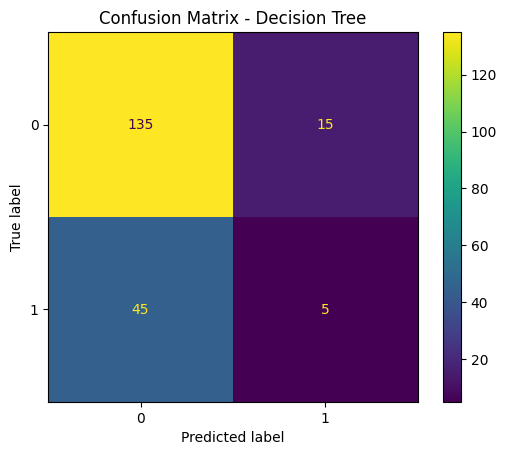

In [27]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

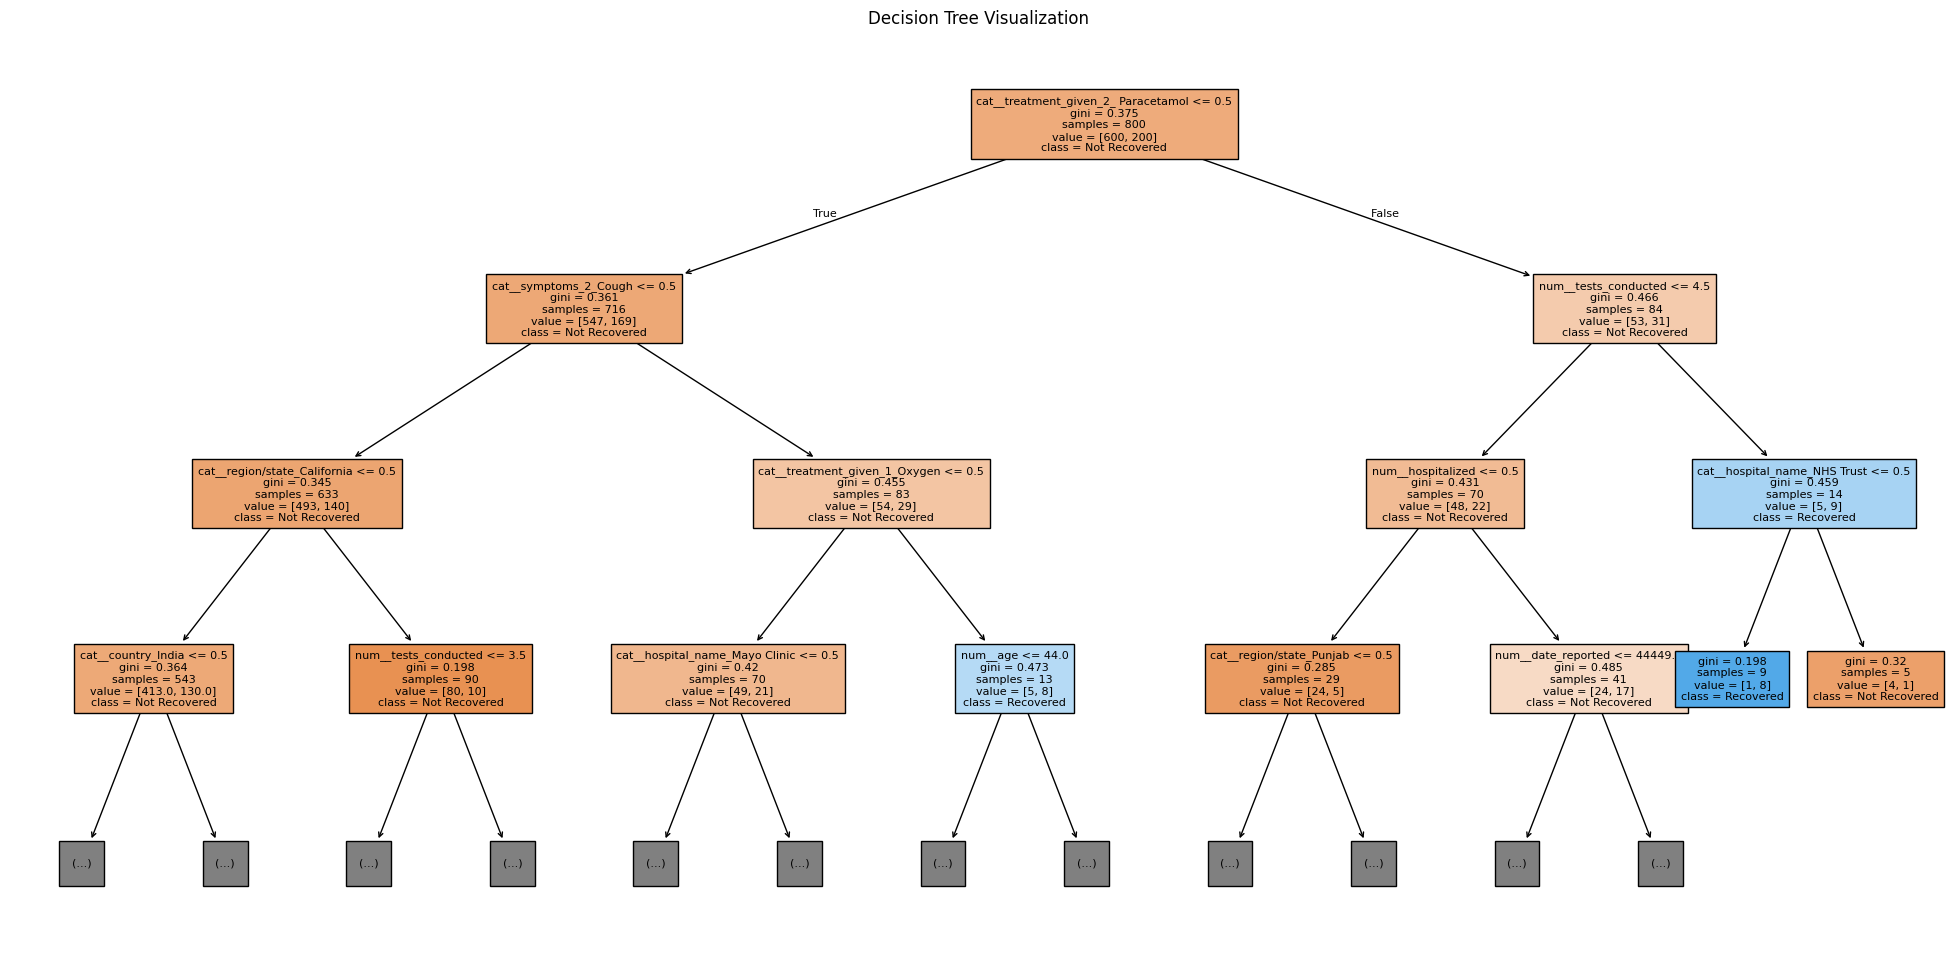

In [28]:
feature_names_after_preprocessing = model.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(25, 12))
plot_tree(
    model.named_steps["classifier"],
    filled=True,
    feature_names=feature_names_after_preprocessing,
    class_names=["Not Recovered", "Recovered"],
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree Visualization")
plt.show()

In [29]:
importances = model.named_steps["classifier"].feature_importances_
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
1,num__age,0.134726
6,num__tests_conducted,0.125817
0,num__date_reported,0.087586
75,cat__hospital_name_NHS Trust,0.069940
74,cat__hospital_name_Mayo Clinic,0.067701
59,cat__treatment_given_1_Oxygen,0.067421
65,cat__treatment_given_2_ Paracetamol,0.060987
54,cat__vaccination_status_Partial,0.060643
17,cat__region/state_California,0.058268
36,cat__symptoms_2_Cough,0.055320


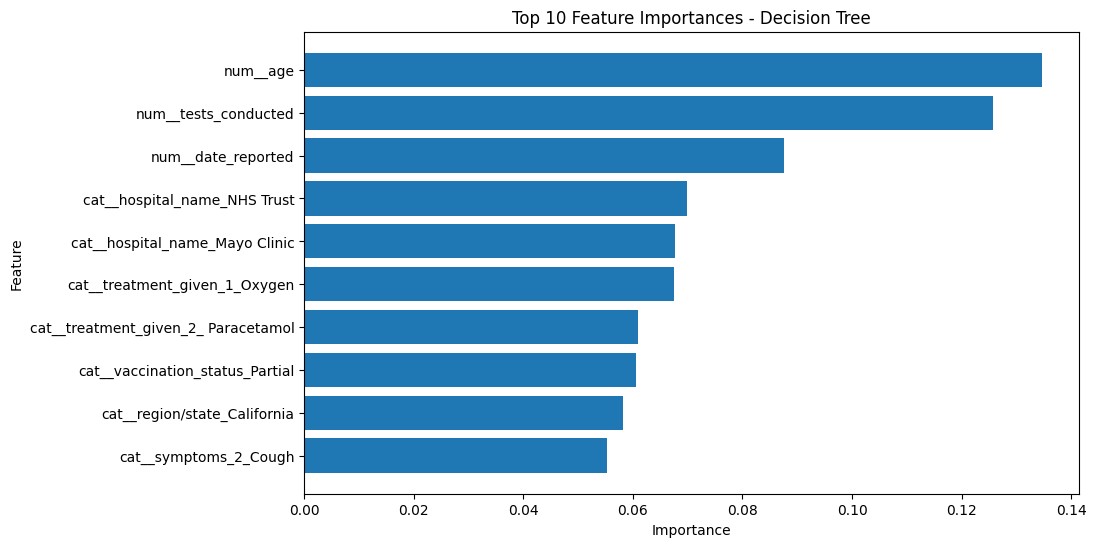

In [30]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"].head(10), importance_df["Importance"].head(10))
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()